# 5.3. 측정에서 얻는 것

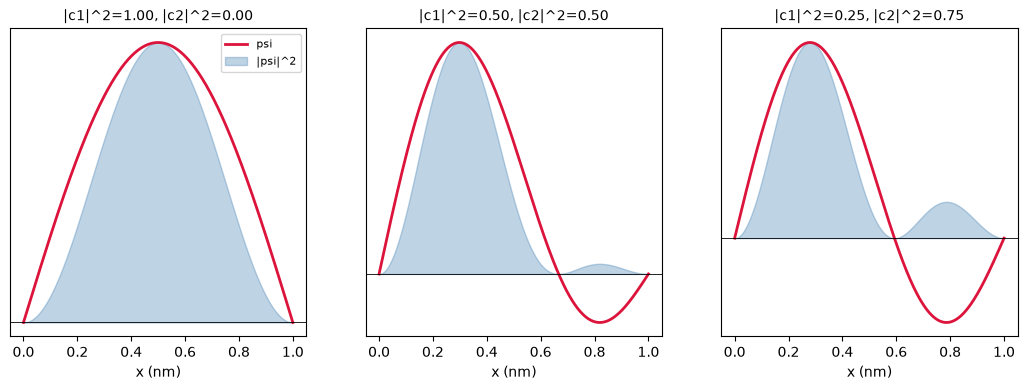

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e, e, h

L, N = 1e-9, 2000
x = np.linspace(0, L, N)


def psi(n):
    return np.sqrt(2 / L) * np.sin(n * np.pi * x / L)


fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, w in zip(axes, [1.0, 0.5, 0.25]):
    a, b = np.sqrt(w), np.sqrt(1 - w)
    P = a * psi(1) + b * psi(2)
    ax.plot(x * 1e9, P / np.abs(P).max(), color="crimson", lw=2, label="psi")
    ax.fill_between(
        x * 1e9, (P**2) / (P**2).max(), color="steelblue", alpha=0.35, label="|psi|^2"
    )
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel("x (nm)")
    ax.set_yticks([])
    ax.set_title(f"|c1|^2={w:.2f}, |c2|^2={1-w:.2f}", fontsize=10)

axes[0].legend(fontsize=8)
plt.show()

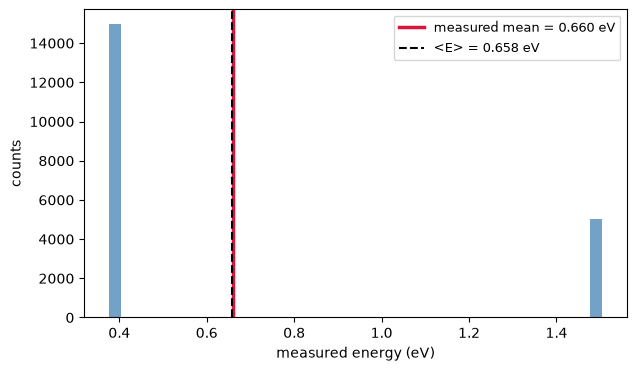

측정 평균 = 0.6598 eV
기댓값    = 0.6581 eV


In [2]:
def En(n):
    return n**2 * h**2 / (8 * m_e * L**2) / e  # 4.1절의 결과, eV 단위


rng = np.random.default_rng(1)
draws = rng.choice([En(1), En(2)], size=20000, p=[0.75, 0.25])

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(draws, bins=40, color="steelblue", alpha=0.75)
ax.axvline(
    draws.mean(),
    color="crimson",
    lw=2.5,
    label=f"measured mean = {draws.mean():.3f} eV",
)
ax.axvline(
    0.75 * En(1) + 0.25 * En(2),
    color="black",
    lw=1.5,
    ls="--",
    label=f"<E> = {0.75 * En(1) + 0.25 * En(2):.3f} eV",
)
ax.set_xlabel("measured energy (eV)")
ax.set_ylabel("counts")
ax.legend(fontsize=9)
plt.show()

print(f"측정 평균 = {draws.mean():.4f} eV")
print(f"기댓값    = {0.75 * En(1) + 0.25 * En(2):.4f} eV")

In [3]:
dx = L / (N + 1)
xg = np.linspace(0, L, N + 2)[1:-1]
D1 = (np.eye(N, k=1) - np.eye(N, k=-1)) / (2 * dx)
D2 = (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2


def psi_g(n):
    return np.sqrt(2 / L) * np.sin(n * np.pi * xg / L)


unit = hbar / L  # 운동량의 자연 단위

for n in [1, 2, 3]:
    p = psi_g(n)
    x_mean = np.trapezoid(p * xg * p, xg)
    x2_mean = np.trapezoid(p * xg**2 * p, xg)
    p_mean = np.trapezoid(p * (-1j * hbar * (D1 @ p)), xg)
    p2_mean = np.trapezoid(p * (-(hbar**2) * (D2 @ p)), xg)
    print(
        f"n={n}:  <x>={x_mean/L:.4f} L   <x^2>={x2_mean/L**2:.4f} L^2   "
        f"<p>={abs(p_mean)/unit:.2e} (h/L)   <p^2>={p2_mean/unit**2:8.4f} (h/L)^2"
    )

n=1:  <x>=0.5000 L   <x^2>=0.2827 L^2   <p>=0.00e+00 (h/L)   <p^2>=  9.8696 (h/L)^2
n=2:  <x>=0.5000 L   <x^2>=0.3207 L^2   <p>=4.35e-16 (h/L)   <p^2>= 39.4784 (h/L)^2
n=3:  <x>=0.5000 L   <x^2>=0.3277 L^2   <p>=2.18e-16 (h/L)   <p^2>= 88.8263 (h/L)^2


In [4]:
c1, c2 = np.sqrt(0.75), np.sqrt(0.25)
Psi_g = c1 * psi_g(1) + c2 * psi_g(2)
H = -(hbar**2) / (2 * m_e) * D2

E_mean = np.trapezoid(Psi_g * (H @ Psi_g), xg) / e

print(f"수치적분으로 구한 <E>           = {E_mean:.5f} eV")
print(f"가중평균 0.75 * E1 + 0.25 * E2 = {0.75 * En(1) + 0.25 * En(2):.5f} eV")

수치적분으로 구한 <E>           = 0.65805 eV
가중평균 0.75 * E1 + 0.25 * E2 = 0.65805 eV
